# Notebook de création de `user_features`

Ce notebook :

- se connecte à PostgreSQL ;
- lit la table `all_event` ;
- exploite `user_event` à titre exploratoire si elle existe ;
- construit un jeu de features utilisateur compact et interprétable ;
- calcule un `clusterability_index` ;
- crée la table `user_features` si nécessaire ;
- recharge son contenu avec les features finales.

L'objectif n'est **pas** de faire le clustering ici, mais de préparer une base propre, compacte et exploitable pour un notebook de segmentation.

In [8]:
# Imports
import warnings
warnings.filterwarnings("ignore")

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sqlalchemy import create_engine, text, inspect
from sqlalchemy.types import BigInteger, Float, Text
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [9]:
# Configuration base de données
DB_CONFIG = {
    "host": "172.18.0.1",
    "database": "postgres",
    "user": "postgres",
    "password": "postgres",
    "port": 5441,
}

def get_engine(db_config=DB_CONFIG):
    url = (
        f"postgresql+psycopg2://{db_config['user']}:{db_config['password']}"
        f"@{db_config['host']}:{db_config['port']}/{db_config['database']}"
    )
    engine = create_engine(url, future=True, pool_pre_ping=True)
    return engine

engine = get_engine()
print("Connexion SQLAlchemy prête.")

Connexion SQLAlchemy prête.


In [10]:
# Test de connexion
with engine.connect() as conn:
    version = conn.execute(text("SELECT version();")).scalar()
print(version)

PostgreSQL 18.1 (Debian 18.1-1.pgdg13+2) on x86_64-pc-linux-gnu, compiled by gcc (Debian 14.2.0-19) 14.2.0, 64-bit


## 1. Fonctions utilitaires

In [11]:
def table_exists(engine, table_name, schema=None):
    inspector = inspect(engine)
    return inspector.has_table(table_name, schema=schema)

def safe_read_sql(query, engine, params=None):
    return pd.read_sql(text(query), engine, params=params)

def get_table_columns(engine, table_name, schema=None):
    inspector = inspect(engine)
    cols = inspector.get_columns(table_name, schema=schema)
    return pd.DataFrame([
        {
            "name": c["name"],
            "type": str(c["type"]),
            "nullable": c.get("nullable", True)
        }
        for c in cols
    ])

def parse_category_levels(series):
    clean = series.fillna("").astype(str).str.strip()
    clean = clean.replace("", np.nan)
    parts = clean.str.split(".", expand=True)
    # garantir 3 colonnes
    for i in range(parts.shape[1], 3):
        parts[i] = np.nan
    parts = parts.iloc[:, :3]
    parts.columns = ["cat_lvl1", "cat_lvl2", "cat_lvl3"]
    return parts

def shannon_entropy(row_values):
    arr = np.asarray(row_values, dtype=float)
    arr = arr[np.isfinite(arr)]
    arr = arr[arr > 0]
    if arr.size == 0:
        return 0.0
    probs = arr / arr.sum()
    return float(-(probs * np.log(probs)).sum())

def minmax_01(s):
    s = pd.Series(s, dtype=float).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    vmin, vmax = s.min(), s.max()
    if vmax == vmin:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - vmin) / (vmax - vmin)

def hopkins_statistic(X, sample_size=500, random_state=42):
    '''
    Approximation simple de la statistique de Hopkins.
    Interprétation:
    - proche de 0.5 : données plutôt aléatoires / peu clusterisables
    - > 0.7 : structure de cluster probable
    '''
    from sklearn.neighbors import NearestNeighbors

    X = np.asarray(X, dtype=float)
    n = X.shape[0]
    if n < 20:
        return np.nan

    rng = np.random.default_rng(random_state)
    m = min(sample_size, max(10, n // 10))
    idx = rng.choice(n, size=m, replace=False)
    X_sample = X[idx]

    mins = X.min(axis=0)
    maxs = X.max(axis=0)
    U = rng.uniform(mins, maxs, size=(m, X.shape[1]))

    nbrs = NearestNeighbors(n_neighbors=2).fit(X)
    u_dist, _ = nbrs.kneighbors(U, n_neighbors=1)
    w_dist, _ = nbrs.kneighbors(X_sample, n_neighbors=2)
    w = w_dist[:, 1]
    u = u_dist[:, 0]

    denom = u.sum() + w.sum()
    if denom == 0:
        return np.nan
    return float(u.sum() / denom)

## 2. Inspection des tables

In [12]:
print("Table all_event existe :", table_exists(engine, "all_event"))
print("Table user_event existe :", table_exists(engine, "user_event"))
print("Table user_features existe :", table_exists(engine, "user_features"))

if table_exists(engine, "all_event"):
    display(get_table_columns(engine, "all_event").head(20))

if table_exists(engine, "user_event"):
    print("\nColonnes de user_event :")
    display(get_table_columns(engine, "user_event").head(50))

Table all_event existe : False
Table user_event existe : False
Table user_features existe : True


In [13]:
# Comptage simple
queries = {
    "all_event_rows": "SELECT COUNT(*) AS n FROM all_event",
    "all_event_users": "SELECT COUNT(DISTINCT user_id) AS n FROM all_event",
}

for name, q in queries.items():
    try:
        df_tmp = safe_read_sql(q, engine)
        print(name, "=", int(df_tmp.iloc[0, 0]))
    except Exception as e:
        print(f"{name} -> erreur: {e}")

all_event_rows -> erreur: (psycopg2.errors.UndefinedTable) relation "all_event" does not exist
LINE 1: SELECT COUNT(*) AS n FROM all_event
                                  ^

[SQL: SELECT COUNT(*) AS n FROM all_event]
(Background on this error at: https://sqlalche.me/e/20/f405)
all_event_users -> erreur: (psycopg2.errors.UndefinedTable) relation "all_event" does not exist
LINE 1: SELECT COUNT(DISTINCT user_id) AS n FROM all_event
                                                 ^

[SQL: SELECT COUNT(DISTINCT user_id) AS n FROM all_event]
(Background on this error at: https://sqlalche.me/e/20/f405)


## 3. Chargement des données utiles

On ne charge que les colonnes nécessaires :

- `event_time`
- `event_type`
- `price`
- `user_id`
- `user_session`
- `category_code`

In [14]:
EVENT_QUERY = '''
SELECT
    event_time,
    event_type,
    price,
    user_id,
    user_session,
    category_code
FROM all_events
WHERE user_id IS NOT NULL
LIMIT 1000
'''

df = safe_read_sql(EVENT_QUERY, engine)
print(df.shape)
df.head()

(1000, 6)


,event_time,event_type,price,user_id,user_session,category_code
0,2019-10-01 07:11:21,view,130.76,555302155,6223b159-6c10-e1ea-a1e8-18a994d3989c,electronics.smartphone
1,2019-10-01 07:11:21,view,16.71,519846080,b27de798-1dc8-4aed-ae35-d6eecb581632,None
2,2019-10-01 07:11:21,view,130.76,555522152,d6793796-a6e7-4fc4-8f2d-cd8b045a6867,electronics.smartphone
3,2019-10-01 07:11:21,view,130.76,555524175,9ee6fac0-db46-415e-9d9a-eeae7c5c7732,electronics.smartphone
4,2019-10-01 07:11:21,view,380.85,515997186,067bfedf-bb9f-479d-887d-4d08cee2129a,appliances.kitchen.washer


In [15]:
# Types et nettoyage de base
df["event_time"] = pd.to_datetime(df["event_time"], errors="coerce", utc=False)
df["event_type"] = df["event_type"].astype(str).str.strip().str.lower()
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df["user_id"] = pd.to_numeric(df["user_id"], errors="coerce").astype("Int64")
df["user_session"] = df["user_session"].astype(str).replace({"": np.nan, "nan": np.nan})
df["category_code"] = df["category_code"].astype(str).replace({"": np.nan, "nan": np.nan})

# Prix aberrants simples
df.loc[df["price"] < 0, "price"] = np.nan

print(df.dtypes)
df.head()

event_time       datetime64[ns]
event_type               object
price                   float64
user_id                   Int64
user_session             object
category_code            object
dtype: object


,event_time,event_type,price,user_id,user_session,category_code
0,2019-10-01 07:11:21,view,130.76,555302155,6223b159-6c10-e1ea-a1e8-18a994d3989c,electronics.smartphone
1,2019-10-01 07:11:21,view,16.71,519846080,b27de798-1dc8-4aed-ae35-d6eecb581632,None
2,2019-10-01 07:11:21,view,130.76,555522152,d6793796-a6e7-4fc4-8f2d-cd8b045a6867,electronics.smartphone
3,2019-10-01 07:11:21,view,130.76,555524175,9ee6fac0-db46-415e-9d9a-eeae7c5c7732,electronics.smartphone
4,2019-10-01 07:11:21,view,380.85,515997186,067bfedf-bb9f-479d-887d-4d08cee2129a,appliances.kitchen.washer


In [16]:
# Qualité des données
quality = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2)
}).sort_values("missing_pct", ascending=False)

display(quality)

print("Distribution event_type")
display(df["event_type"].value_counts(dropna=False))

print("Nombre d'utilisateurs uniques :", df["user_id"].nunique())

,missing_count,missing_pct
event_time,0,0.0
event_type,0,0.0
price,0,0.0
user_id,0,0.0
user_session,0,0.0
category_code,0,0.0


Distribution event_type


event_type
view        973
purchase     16
cart         11
Name: count, dtype: int64

Nombre d'utilisateurs uniques : 706


## 4. Parsing de `category_code`

On garde les 3 niveaux à titre analytique, mais **seul `cat_lvl1`** sera utilisé pour les features finales afin d'éviter une matrice trop sparse.

In [17]:
cat_levels = parse_category_levels(df["category_code"])
df = pd.concat([df, cat_levels], axis=1)

display(df[["category_code", "cat_lvl1", "cat_lvl2", "cat_lvl3"]].head(10))
print("Top catégories niveau 1 :")
display(df["cat_lvl1"].value_counts(dropna=False).head(15))

,category_code,cat_lvl1,cat_lvl2,cat_lvl3
0,electronics.smartphone,electronics,smartphone,None
1,None,None,None,None
2,electronics.smartphone,electronics,smartphone,None
3,electronics.smartphone,electronics,smartphone,None
4,appliances.kitchen.washer,appliances,kitchen,washer
5,electronics.smartphone,electronics,smartphone,None
6,appliances.kitchen.refrigerators,appliances,kitchen,refrigerators
7,electronics.smartphone,electronics,smartphone,None
8,None,None,None,None
9,appliances.environment.air_conditioner,appliances,environment,air_conditioner


Top catégories niveau 1 :


cat_lvl1
electronics     404
None            311
appliances      119
computers        52
auto             37
apparel          23
furniture        19
construction     15
kids             13
accessories       5
sport             2
Name: count, dtype: int64

## 5. Construction des features comportementales et monétaires

In [18]:
def build_behavior_features(events: pd.DataFrame) -> pd.DataFrame:
    base = pd.DataFrame(index=pd.Index(sorted(events["user_id"].dropna().unique()), name="user_id"))

    # Volumes
    user_group = events.groupby("user_id")
    base["nb_events"] = user_group.size()
    base["nb_sessions"] = user_group["user_session"].nunique(dropna=True)

    et_counts = (
        events.groupby(["user_id", "event_type"])
        .size()
        .unstack(fill_value=0)
    )

    for col in ["view", "cart", "purchase"]:
        if col not in et_counts.columns:
            et_counts[col] = 0

    base["nb_views"] = et_counts["view"]
    base["nb_cart"] = et_counts["cart"]
    base["nb_purchases"] = et_counts["purchase"]

    # Ratios
    base["purchase_rate"] = base["nb_purchases"] / base["nb_events"].replace(0, np.nan)
    base["cart_rate"] = base["nb_cart"] / base["nb_events"].replace(0, np.nan)
    base["session_intensity"] = base["nb_events"] / base["nb_sessions"].replace(0, np.nan)

    # Monétaire
    view_mask = events["event_type"].eq("view")
    purchase_mask = events["event_type"].eq("purchase")

    avg_view_price = events.loc[view_mask].groupby("user_id")["price"].mean()
    avg_purchase_price = events.loc[purchase_mask].groupby("user_id")["price"].mean()
    total_spent = events.loc[purchase_mask].groupby("user_id")["price"].sum()

    base["avg_price_viewed"] = avg_view_price
    base["avg_price_purchased"] = avg_purchase_price
    base["total_spent"] = total_spent
    base["monetary_per_session"] = base["total_spent"] / base["nb_sessions"].replace(0, np.nan)

    return base

behavior_features = build_behavior_features(df)
behavior_features.head()

,nb_events,nb_sessions,nb_views,nb_cart,nb_purchases,purchase_rate,cart_rate,session_intensity,avg_price_viewed,avg_price_purchased,total_spent,monetary_per_session
user_id,,,,,,,,,,,,
477006909,3,1,3,0,0,0.0,0.0,3.0,390.186667,NaN,NaN,NaN
501520882,1,1,1,0,0,0.0,0.0,1.0,130.760000,NaN,NaN,NaN
512367742,1,1,1,0,0,0.0,0.0,1.0,382.980000,NaN,NaN,NaN
512373660,1,1,1,0,0,0.0,0.0,1.0,97.710000,NaN,NaN,NaN
512374050,3,1,3,0,0,0.0,0.0,3.0,80.800000,NaN,NaN,NaN


## 6. Construction des features liées aux catégories

On ne veut **pas** encoder toutes les catégories.  
On sélectionne seulement les catégories niveau 1 les plus fréquentes dans le dataset global.

In [19]:
TOP_N_CATEGORIES = 4

top_categories = (
    df["cat_lvl1"]
    .dropna()
    .value_counts()
    .head(TOP_N_CATEGORIES)
    .index
    .tolist()
)

print("Top catégories retenues :", top_categories)

Top catégories retenues : ['electronics', 'None', 'appliances', 'computers']


In [20]:
def build_category_features(events: pd.DataFrame, top_categories: list) -> pd.DataFrame:
    tmp = events.copy()
    tmp["cat_lvl1_clean"] = tmp["cat_lvl1"].fillna("unknown")

    # Nombre de catégories distinctes niveau 1
    distinct_cat = tmp.groupby("user_id")["cat_lvl1_clean"].nunique()

    # Tableau user x catégorie
    cat_counts = (
        tmp.groupby(["user_id", "cat_lvl1_clean"])
        .size()
        .unstack(fill_value=0)
    )

    # Entropie
    cat_ratio_full = cat_counts.div(cat_counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
    entropy = cat_ratio_full.apply(lambda r: shannon_entropy(r.values), axis=1)

    # Catégorie dominante
    dominant_category = cat_counts.idxmax(axis=1)

    # Ratios sur top catégories seulement
    selected = pd.DataFrame(index=cat_counts.index)
    total_events_user = cat_counts.sum(axis=1).replace(0, np.nan)

    for cat in top_categories:
        if cat in cat_counts.columns:
            selected[f"ratio_{cat}"] = cat_counts[cat] / total_events_user
        else:
            selected[f"ratio_{cat}"] = 0.0

    selected["nb_distinct_cat_lvl1"] = distinct_cat
    selected["category_entropy"] = entropy
    selected["dominant_category"] = dominant_category

    return selected

category_features = build_category_features(df, top_categories)
category_features.head()

,ratio_electronics,ratio_None,ratio_appliances,ratio_computers,nb_distinct_cat_lvl1,category_entropy,dominant_category
user_id,,,,,,,
477006909,1.0,0.0,0.0,0.0,1,-0.0,electronics
501520882,1.0,0.0,0.0,0.0,1,-0.0,electronics
512367742,0.0,0.0,0.0,1.0,1,-0.0,computers
512373660,0.0,1.0,0.0,0.0,1,-0.0,None
512374050,0.0,1.0,0.0,0.0,1,-0.0,None


## 7. Assemblage des features

On garde une matrice compacte, interprétable et plus adaptée au clustering.

In [21]:
df_user_features = behavior_features.join(category_features, how="left")

# Nettoyage numérique
numeric_cols = [c for c in df_user_features.columns if c != "dominant_category"]
for c in numeric_cols:
    df_user_features[c] = pd.to_numeric(df_user_features[c], errors="coerce")

df_user_features = df_user_features.replace([np.inf, -np.inf], np.nan)

# Valeurs par défaut raisonnables
fill_zero_cols = [
    "nb_events", "nb_sessions", "nb_views", "nb_cart", "nb_purchases",
    "purchase_rate", "cart_rate", "session_intensity",
    "avg_price_viewed", "avg_price_purchased",
    "total_spent", "monetary_per_session",
    "nb_distinct_cat_lvl1", "category_entropy"
] + [c for c in df_user_features.columns if c.startswith("ratio_")]

for c in fill_zero_cols:
    if c in df_user_features.columns:
        df_user_features[c] = df_user_features[c].fillna(0.0)

df_user_features["dominant_category"] = df_user_features["dominant_category"].fillna("unknown")

df_user_features.head()

,nb_events,nb_sessions,nb_views,nb_cart,nb_purchases,purchase_rate,cart_rate,session_intensity,avg_price_viewed,avg_price_purchased,total_spent,monetary_per_session,ratio_electronics,ratio_None,ratio_appliances,ratio_computers,nb_distinct_cat_lvl1,category_entropy,dominant_category
user_id,,,,,,,,,,,,,,,,,,,
477006909,3,1,3,0,0,0.0,0.0,3.0,390.186667,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,-0.0,electronics
501520882,1,1,1,0,0,0.0,0.0,1.0,130.760000,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,-0.0,electronics
512367742,1,1,1,0,0,0.0,0.0,1.0,382.980000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,-0.0,computers
512373660,1,1,1,0,0,0.0,0.0,1.0,97.710000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,-0.0,None
512374050,3,1,3,0,0,0.0,0.0,3.0,80.800000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,-0.0,None


## 8. Sélection compacte des colonnes finales

On supprime volontairement quelques colonnes redondantes :

- `nb_views` souvent corrélé à `nb_events`
- `nb_cart` peut être redondant avec `cart_rate`
- `avg_price_purchased` indisponible pour trop d'utilisateurs sans achat

La table finale reste compacte pour améliorer la stabilité d'un futur clustering.

In [22]:
candidate_numeric_features = [
    "nb_events",
    "nb_sessions",
    "nb_purchases",
    "purchase_rate",
    "session_intensity",
    "total_spent",
    "avg_price_viewed",
    "nb_distinct_cat_lvl1",
    "category_entropy",
] + [c for c in df_user_features.columns if c.startswith("ratio_")]

candidate_numeric_features

['nb_events',
 'nb_sessions',
 'nb_purchases',
 'purchase_rate',
 'session_intensity',
 'total_spent',
 'avg_price_viewed',
 'nb_distinct_cat_lvl1',
 'category_entropy',
 'ratio_electronics',
 'ratio_None',
 'ratio_appliances',
 'ratio_computers']

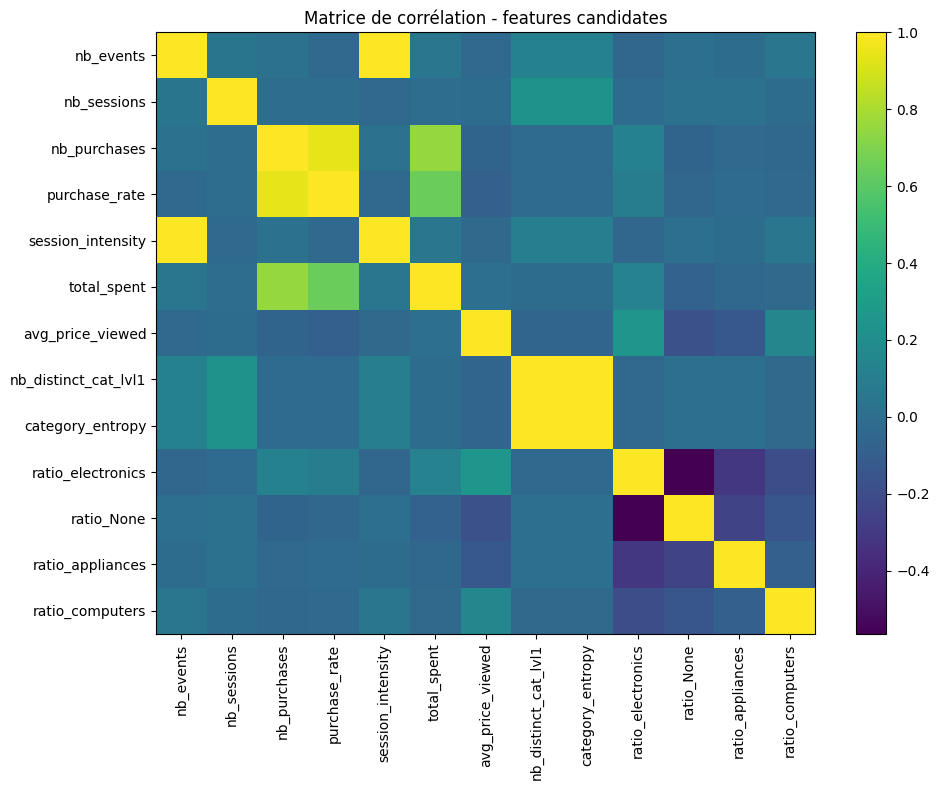

,nb_events,nb_sessions,nb_purchases,purchase_rate,session_intensity,total_spent,avg_price_viewed,nb_distinct_cat_lvl1,category_entropy,ratio_electronics,ratio_None,ratio_appliances,ratio_computers
nb_events,1.00,0.04,0.02,-0.03,1.00,0.05,-0.03,0.12,0.12,-0.05,0.01,-0.01,0.05
nb_sessions,0.04,1.00,-0.01,-0.01,-0.03,-0.01,-0.01,0.23,0.24,-0.02,0.02,0.02,-0.01
nb_purchases,0.02,-0.01,1.00,0.94,0.02,0.75,-0.06,-0.02,-0.02,0.12,-0.06,-0.03,-0.03
purchase_rate,-0.03,-0.01,0.94,1.00,-0.03,0.64,-0.08,-0.02,-0.02,0.10,-0.05,-0.02,-0.03
session_intensity,1.00,-0.03,0.02,-0.03,1.00,0.05,-0.03,0.11,0.10,-0.05,0.01,-0.01,0.05
total_spent,0.05,-0.01,0.75,0.64,0.05,1.00,0.01,-0.01,-0.01,0.13,-0.07,-0.04,-0.03
avg_price_viewed,-0.03,-0.01,-0.06,-0.08,-0.03,0.01,1.00,-0.05,-0.05,0.26,-0.17,-0.13,0.16
nb_distinct_cat_lvl1,0.12,0.23,-0.02,-0.02,0.11,-0.01,-0.05,1.00,1.00,-0.03,0.01,0.01,-0.03
category_entropy,0.12,0.24,-0.02,-0.02,0.10,-0.01,-0.05,1.00,1.00,-0.03,0.01,0.01,-0.03
ratio_electronics,-0.05,-0.02,0.12,0.10,-0.05,0.13,0.26,-0.03,-0.03,1.00,-0.56,-0.31,-0.19


In [23]:
# Corrélations pour vérifier la redondance
corr = df_user_features[candidate_numeric_features].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.title("Matrice de corrélation - features candidates")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.tight_layout()
plt.show()

corr.round(2)

In [24]:
# Liste finale retenue
final_feature_cols = [
    "nb_events",
    "nb_sessions",
    "nb_purchases",
    "purchase_rate",
    "session_intensity",
    "total_spent",
    "avg_price_viewed",
    "nb_distinct_cat_lvl1",
    "category_entropy",
] + [c for c in df_user_features.columns if c.startswith("ratio_")]

final_feature_cols

['nb_events',
 'nb_sessions',
 'nb_purchases',
 'purchase_rate',
 'session_intensity',
 'total_spent',
 'avg_price_viewed',
 'nb_distinct_cat_lvl1',
 'category_entropy',
 'ratio_electronics',
 'ratio_None',
 'ratio_appliances',
 'ratio_computers']

## 9. Calcul du `clusterability_index`

Ce score ne prédit pas un cluster.  
Il mesure si un utilisateur possède suffisamment de signal comportemental pour être segmenté de façon fiable.

Le score combine :

- richesse d'événements ;
- richesse de sessions ;
- diversité catégorielle ;
- entropie de navigation ;
- présence d'achat / panier.

Le score final est borné entre 0 et 100.

In [25]:
def compute_clusterability_index(feature_df: pd.DataFrame) -> pd.DataFrame:
    out = feature_df.copy()

    event_signal = minmax_01(np.log1p(out["nb_events"]))
    session_signal = minmax_01(np.log1p(out["nb_sessions"]))
    category_signal = minmax_01(out["nb_distinct_cat_lvl1"])
    entropy_signal = minmax_01(out["category_entropy"])
    action_signal = (
        0.6 * minmax_01(out["purchase_rate"]) +
        0.4 * minmax_01((out["nb_purchases"] > 0).astype(int))
    )

    score_01 = (
        0.30 * event_signal +
        0.20 * session_signal +
        0.20 * category_signal +
        0.15 * entropy_signal +
        0.15 * action_signal
    )

    out["clusterability_index"] = (score_01 * 100).round(2)

    out["clusterability_band"] = pd.cut(
        out["clusterability_index"],
        bins=[-0.01, 33, 66, 100],
        labels=["low_information", "medium_information", "high_information"]
    ).astype(str)

    return out

df_user_features = compute_clusterability_index(df_user_features)
df_user_features.head()

,nb_events,nb_sessions,nb_views,nb_cart,nb_purchases,purchase_rate,cart_rate,session_intensity,avg_price_viewed,avg_price_purchased,...,monetary_per_session,ratio_electronics,ratio_None,ratio_appliances,ratio_computers,nb_distinct_cat_lvl1,category_entropy,dominant_category,clusterability_index,clusterability_band
user_id,,,,,,,,,,,,,,,,,,,,,
477006909,3,1,3,0,0,0.0,0.0,3.0,390.186667,0.0,...,0.0,1.0,0.0,0.0,0.0,1,-0.0,electronics,15.0,low_information
501520882,1,1,1,0,0,0.0,0.0,1.0,130.760000,0.0,...,0.0,1.0,0.0,0.0,0.0,1,-0.0,electronics,0.0,low_information
512367742,1,1,1,0,0,0.0,0.0,1.0,382.980000,0.0,...,0.0,0.0,0.0,0.0,1.0,1,-0.0,computers,0.0,low_information
512373660,1,1,1,0,0,0.0,0.0,1.0,97.710000,0.0,...,0.0,0.0,1.0,0.0,0.0,1,-0.0,None,0.0,low_information
512374050,3,1,3,0,0,0.0,0.0,3.0,80.800000,0.0,...,0.0,0.0,1.0,0.0,0.0,1,-0.0,None,15.0,low_information


## 10. Validation rapide de la matrice de features

In [26]:
# Distribution des features principales
df_user_features[final_feature_cols + ["clusterability_index"]].describe().T

,count,mean,std,min,25%,50%,75%,max
nb_events,706.0,1.416431,0.745263,1.0,1.000,1.0000,2.00,7.000000
nb_sessions,706.0,1.002833,0.053187,1.0,1.000,1.0000,1.00,2.000000
nb_purchases,706.0,0.022663,0.148932,0.0,0.000,0.0000,0.00,1.000000
purchase_rate,706.0,0.017941,0.124883,0.0,0.000,0.0000,0.00,1.000000
session_intensity,706.0,1.413598,0.744940,1.0,1.000,1.0000,2.00,7.000000
total_spent,706.0,7.554518,65.901063,0.0,0.000,0.0000,0.00,975.570000
avg_price_viewed,706.0,305.496283,396.693178,0.0,63.955,155.5925,372.03,2574.040000
nb_distinct_cat_lvl1,706.0,1.012748,0.112264,1.0,1.000,1.0000,1.00,2.000000
category_entropy,706.0,0.008676,0.076449,-0.0,0.000,-0.0000,-0.00,0.693147
ratio_electronics,706.0,0.415958,0.491475,0.0,0.000,0.0000,1.00,1.000000


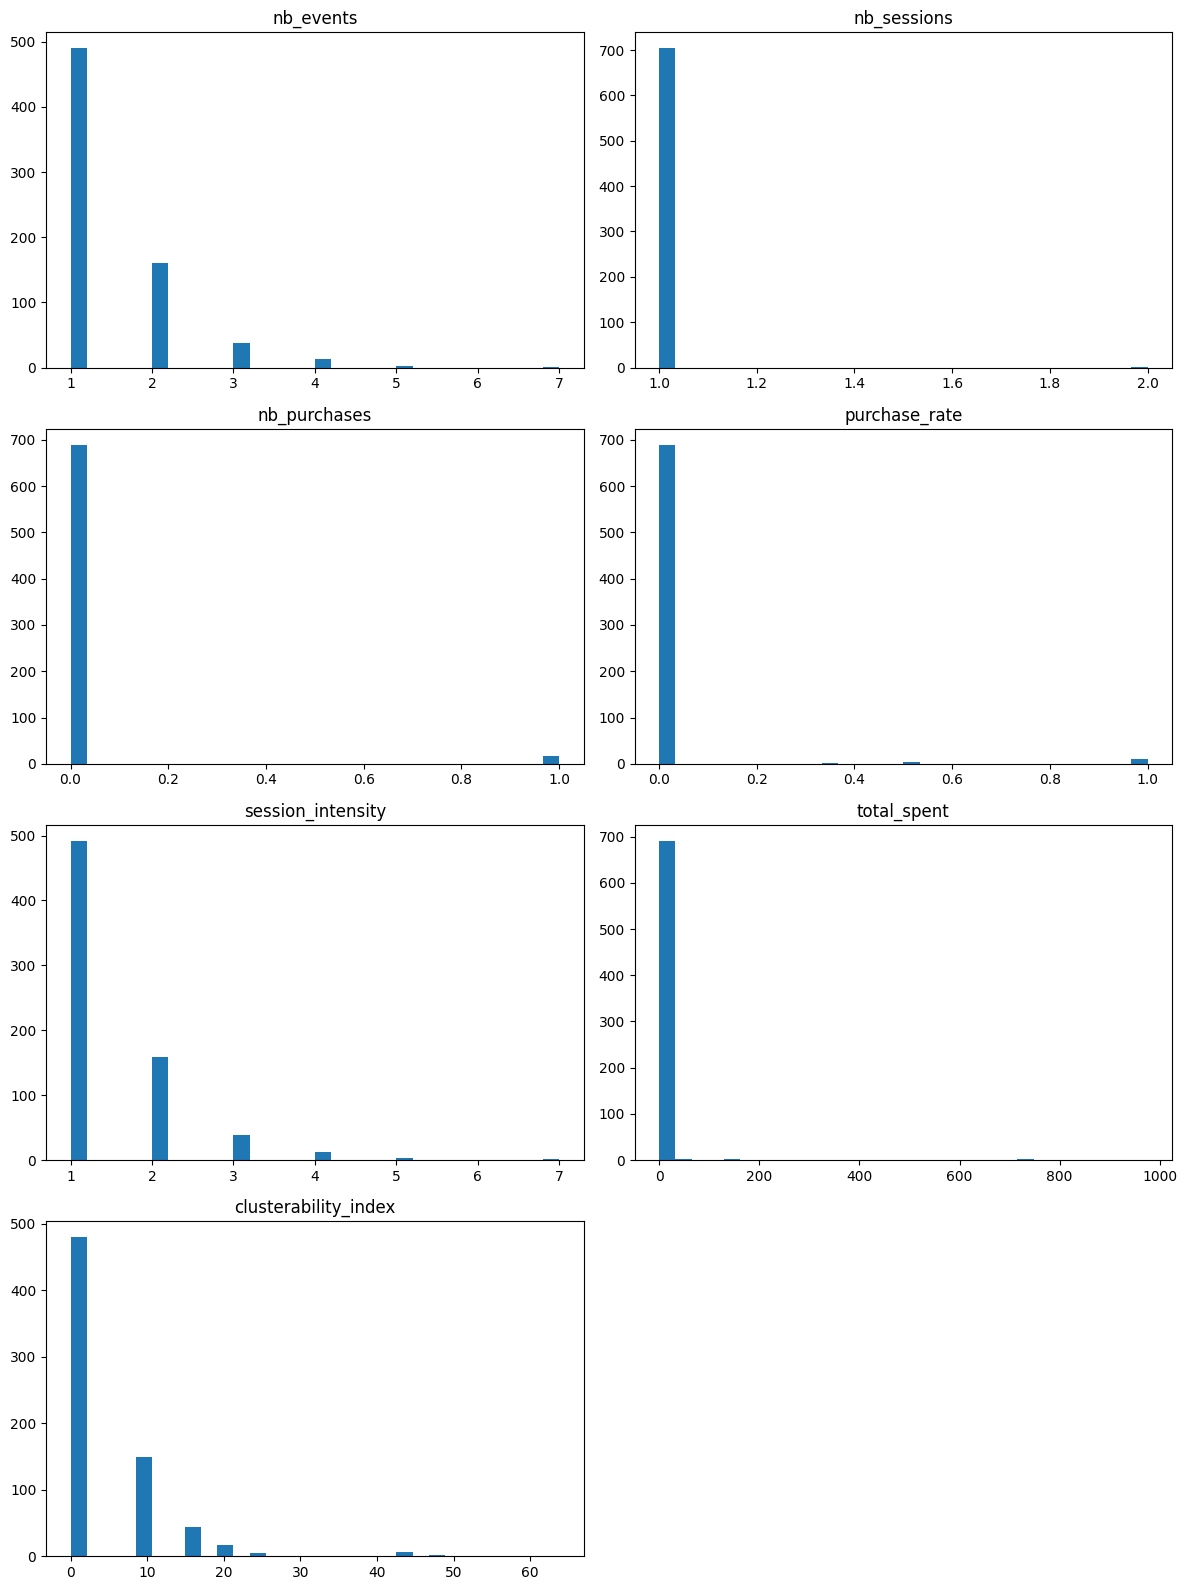

In [27]:
# Histogrammes simples
plot_cols = final_feature_cols[:6] + ["clusterability_index"]

n = len(plot_cols)
fig, axes = plt.subplots(math.ceil(n/2), 2, figsize=(12, 4 * math.ceil(n/2)))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, plot_cols):
    ax.hist(df_user_features[col].fillna(0), bins=30)
    ax.set_title(col)

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [28]:
# Préparation matrice standardisée
X = df_user_features[final_feature_cols].copy().fillna(0.0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape matrice clustering :", X_scaled.shape)

Shape matrice clustering : (706, 13)


In [29]:
# Diagnostic de clusterisabilité : Hopkins + petit test KMeans
hopkins = hopkins_statistic(X_scaled, sample_size=min(500, len(X)))
print("Hopkins statistic =", hopkins)

silhouette_kmeans = np.nan
if len(X) >= 50:
    try:
        km = KMeans(n_clusters=4, random_state=42, n_init=10)
        labels = km.fit_predict(X_scaled)
        if len(np.unique(labels)) > 1:
            silhouette_kmeans = silhouette_score(X_scaled, labels)
    except Exception as e:
        print("Silhouette test impossible :", e)

print("Silhouette proxy (KMeans k=4) =", silhouette_kmeans)

Hopkins statistic = 0.9965057825221275
Silhouette proxy (KMeans k=4) = 0.31349211376471814


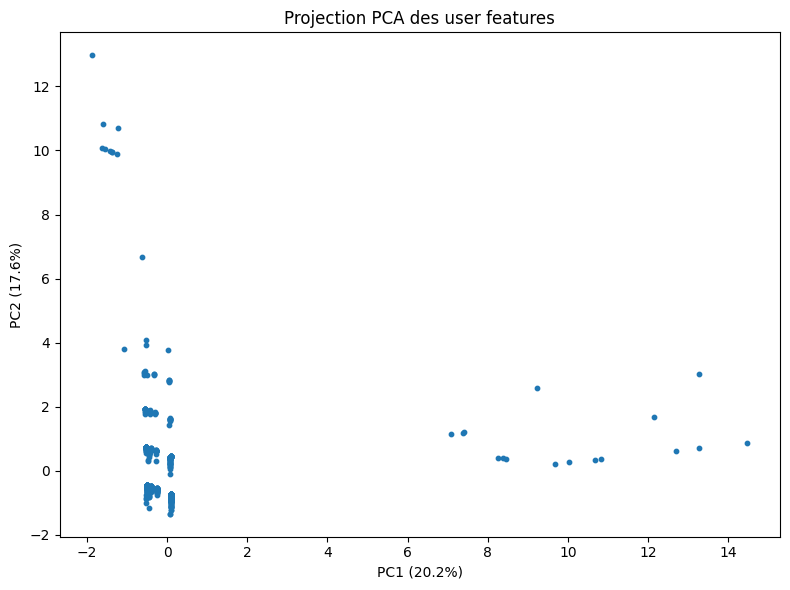

Variance expliquée cumulée 2D = 0.3781002773055353


In [30]:
# PCA pour visualisation rapide
if len(X) >= 2:
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], s=10)
    plt.title("Projection PCA des user features")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    plt.tight_layout()
    plt.show()

    print("Variance expliquée cumulée 2D =", pca.explained_variance_ratio_.sum())

## 11. Préparation de la table finale PostgreSQL

La table contiendra :

- `user_id`
- features numériques finales
- `clusterability_index`
- `clusterability_band`
- `dominant_category`
- `created_at`

In [31]:
# DataFrame final à stocker
storage_cols = ["user_id"] + final_feature_cols + ["clusterability_index", "clusterability_band", "dominant_category"]

df_store = (
    df_user_features
    .reset_index()[storage_cols]
    .copy()
)

df_store["created_at"] = pd.Timestamp.utcnow().tz_localize(None)

print(df_store.shape)
df_store.head()

(706, 18)


,user_id,nb_events,nb_sessions,nb_purchases,purchase_rate,session_intensity,total_spent,avg_price_viewed,nb_distinct_cat_lvl1,category_entropy,ratio_electronics,ratio_None,ratio_appliances,ratio_computers,clusterability_index,clusterability_band,dominant_category,created_at
0,477006909,3,1,0,0.0,3.0,0.0,390.186667,1,-0.0,1.0,0.0,0.0,0.0,15.0,low_information,electronics,2026-03-07 14:47:02.726640
1,501520882,1,1,0,0.0,1.0,0.0,130.760000,1,-0.0,1.0,0.0,0.0,0.0,0.0,low_information,electronics,2026-03-07 14:47:02.726640
2,512367742,1,1,0,0.0,1.0,0.0,382.980000,1,-0.0,0.0,0.0,0.0,1.0,0.0,low_information,computers,2026-03-07 14:47:02.726640
3,512373660,1,1,0,0.0,1.0,0.0,97.710000,1,-0.0,0.0,1.0,0.0,0.0,0.0,low_information,None,2026-03-07 14:47:02.726640
4,512374050,3,1,0,0.0,3.0,0.0,80.800000,1,-0.0,0.0,1.0,0.0,0.0,15.0,low_information,None,2026-03-07 14:47:02.726640


In [32]:
def create_user_features_table(engine, df_store: pd.DataFrame):
    numeric_cols_sql = []
    for c in df_store.columns:
        if c in ["user_id", "clusterability_band", "dominant_category", "created_at"]:
            continue
        numeric_cols_sql.append(f'"{c}" DOUBLE PRECISION')

    create_sql = f'''
    CREATE TABLE IF NOT EXISTS user_features (
        user_id BIGINT PRIMARY KEY,
        {", ".join(numeric_cols_sql)},
        clusterability_band TEXT,
        dominant_category TEXT,
        created_at TIMESTAMP
    );
    '''
    with engine.begin() as conn:
        conn.execute(text(create_sql))

create_user_features_table(engine, df_store)
print("Table user_features créée ou déjà existante.")

Table user_features créée ou déjà existante.


In [33]:
def reload_user_features(engine, df_store: pd.DataFrame):
    # stratégie simple et robuste : TRUNCATE + reload complet
    with engine.begin() as conn:
        conn.execute(text("TRUNCATE TABLE user_features;"))

    dtype_map = {
        "user_id": BigInteger(),
        "clusterability_band": Text(),
        "dominant_category": Text(),
    }
    for c in df_store.columns:
        if c not in dtype_map and c != "created_at":
            if c != "user_id":
                dtype_map[c] = Float()

    df_store.to_sql(
        "user_features",
        engine,
        if_exists="append",
        index=False,
        method="multi",
        chunksize=10000,
        dtype=dtype_map,
    )

reload_user_features(engine, df_store)
print("Rechargement de user_features terminé.")

ProgrammingError: (psycopg2.errors.UndefinedColumn) column "avg_price_viewed" of relation "user_features" does not exist
LINE 1: ...s, purchase_rate, session_intensity, total_spent, avg_price_...
                                                             ^

[SQL: INSERT INTO user_features (user_id, nb_events, nb_sessions, nb_purchases, purchase_rate, session_intensity, total_spent, avg_price_viewed, nb_distinct_cat_lvl1, category_entropy, ratio_electronics, "ratio_None", ratio_appliances, ratio_computers, clusterability_index, clusterability_band, dominant_category, created_at) VALUES (%(user_id_m0)s, %(nb_events_m0)s, %(nb_sessions_m0)s, %(nb_purchases_m0)s, %(purchase_rate_m0)s, %(session_intensity_m0)s, %(total_spent_m0)s, %(avg_price_viewed_m0)s, %(nb_distinct_cat_lvl1_m0)s, %(category_entropy_m0)s, %(ratio_electronics_m0)s, %(ratio_None_m0)s, %(ratio_appliances_m0)s, %(ratio_computers_m0)s, %(clusterability_index_m0)s, %(clusterability_band_m0)s, %(dominant_category_m0)s, %(crea

In [ ]:
# Vérification finale
check_count = safe_read_sql("SELECT COUNT(*) AS n FROM user_features", engine)
display(check_count)

preview = safe_read_sql("SELECT * FROM user_features LIMIT 10", engine)
display(preview)

## 12. Synthèse finale

In [ ]:
print("Nombre de lignes dans user_features :", len(df_store))
print("\nColonnes retenues pour le clustering futur :")
for c in final_feature_cols:
    print("-", c)

print("\nRépartition du clusterability_band :")
display(df_store["clusterability_band"].value_counts(dropna=False))

print("\nStatistiques clusterability_index :")
display(df_store["clusterability_index"].describe())

## Recommandation métier

Cette table `user_features` peut être utilisée par l'équipe marketing pour segmenter les utilisateurs selon :

- leur intensité de navigation ;
- leur niveau d'achat ;
- leur sensibilité à certaines grandes familles de produits ;
- leur diversité d'exploration catalogue ;
- leur maturité comportementale via `clusterability_index`.

Étape suivante recommandée :

1. standardiser les variables ;
2. tester plusieurs modèles de clustering (`KMeans`, `Agglomerative`, `GMM`) ;
3. comparer les scores (`silhouette`, `davies-bouldin`, `calinski-harabasz`) ;
4. nommer les segments avec une lecture métier :
   - explorateurs ;
   - acheteurs engagés ;
   - spécialistes d'une catégorie ;
   - visiteurs peu informatifs.